# IoT-Enabled Supply Chain Monitoring

**Final project analysis notebook**

This notebook prepares the uploaded IoT shipment prototype data, builds explanatory Plotly visuals, and frames the dashboard story around cold-chain risk detection and supply-chain transparency.

> Dataset integrity note: the uploaded shipment readings are simulated prototype data. They are useful for dashboard development and scenario analysis, but the final assessed version should integrate a credible real-world logistics or IoT sensor dataset.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

pd.set_option("display.max_columns", None)

DATA = Path("../data/processed")
shipments = pd.read_csv(DATA / "clean_supply_chain_prototype.csv", parse_dates=["timestamp"])
summary = pd.read_csv(DATA / "shipment_summary_prototype.csv", parse_dates=["start_time", "end_time"])
batch = pd.read_csv(DATA / "batch_results.csv")

shipments.head()

,shipment_id,step,timestamp,hour,lat,lon,temperature_c,temp_threshold_c,temp_alert,interval_co2_kg,cumulative_co2_kg,distance_km,source_file,data_type,alert,temperature_difference_c,journey_progress_pct,risk_level,journey_stage,hour_bucket
0,A-104,0,2026-07-04 17:24:49,0.000,52.52020,13.40432,4.98,11.0,False,4.249,4.249,0.00,shipment_A-104.csv,simulated_prototype,0,-6.02,0.000000,Normal,0-25%,0-3h
1,A-104,1,2026-07-04 17:29:49,0.083,52.51612,13.34357,5.16,11.0,False,3.823,8.072,4.55,shipment_A-104.csv,simulated_prototype,0,-5.84,0.694656,Normal,0-25%,0-3h
2,A-104,2,2026-07-04 17:34:49,0.167,52.51162,13.28033,5.08,11.0,False,3.784,11.856,9.10,shipment_A-104.csv,simulated_prototype,0,-5.92,1.389313,Normal,0-25%,0-3h
3,A-104,3,2026-07-04 17:39:49,0.250,52.50716,13.21923,5.28,11.0,False,4.123,15.979,13.65,shipment_A-104.csv,simulated_prototype,0,-5.72,2.083969,Normal,0-25%,0-3h
4,A-104,4,2026-07-04 17:44:49,0.333,52.50305,13.15715,5.08,11.0,False,4.294,20.273,18.19,shipment_A-104.csv,simulated_prototype,0,-5.92,2.777099,Normal,0-25%,0-3h


## 1. Preliminary EDA

These checks describe the data. They **do not count** as the required analytical questions.

In [2]:
print("Rows:", len(shipments))
print("Shipments:", shipments["shipment_id"].nunique())
print("Date range:", shipments["timestamp"].min(), "to", shipments["timestamp"].max())
shipments.describe()

Rows: 580
Shipments: 4
Date range: 2026-07-04 17:24:49 to 2026-07-29 02:49:41


,step,timestamp,hour,lat,lon,temperature_c,temp_threshold_c,interval_co2_kg,cumulative_co2_kg,distance_km,alert,temperature_difference_c,journey_progress_pct
count,580.000000,580,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000
mean,72.000000,2026-07-12 07:54:32.250000,6.000000,52.222187,8.941313,5.505724,8.875000,3.838710,279.780455,306.875000,0.025862,-3.369276,50.000000
min,0.000000,2026-07-04 17:24:49,0.000000,51.923720,4.477430,4.000000,8.000000,2.880000,3.356000,0.000000,0.000000,-6.780000,0.000000
25%,36.000000,2026-07-06 22:07:22,3.000000,52.073010,6.709778,5.010000,8.000000,3.647750,138.909750,149.902500,0.000000,-3.890000,25.000000
50%,72.000000,2026-07-07 17:41:49.500000,6.000000,52.221805,8.940990,5.330000,8.250000,3.977500,275.295000,302.430000,0.000000,-3.030000,50.000000
75%,108.000000,2026-07-13 03:28:59.750000,9.000000,52.371640,11.173800,5.600000,9.125000,4.186750,413.163500,455.120000,0.000000,-2.640000,75.000000
max,144.000000,2026-07-29 02:49:41,12.000000,52.520200,13.405540,12.800000,11.000000,4.419000,595.863000,655.000000,1.000000,4.800000,100.000000
std,41.893029,NaN,3.491088,0.173261,2.597163,1.102114,1.244808,0.451747,164.497468,182.560323,0.158861,1.630073,29.092388


In [3]:
missing = shipments.isna().sum().to_frame("missing_values")
missing

,missing_values
shipment_id,0
step,0
timestamp,0
hour,0
lat,0
lon,0
temperature_c,0
temp_threshold_c,0
temp_alert,0
interval_co2_kg,0


In [4]:
summary.round(2)

C:\Users\AbubakarDangiUmar\AppData\Local\Temp\ipykernel_9688\4160917781.py:1: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  summary.round(2)


,shipment_id,start_time,end_time,readings,threshold_c,total_distance_km,total_co2_kg,mean_temperature_c,max_temperature_c,temperature_variability_sd,alert_readings,first_alert_hour,last_alert_hour,alert_duration_hours,share_readings_in_alert_pct
0,A-104,2026-07-04 17:24:49,2026-07-05 05:24:49,145,11.0,655.0,595.86,5.57,8.88,0.97,0,NaN,NaN,0.00,0.00
1,A-1041,2026-07-07 11:42:06,2026-07-07 23:42:06,145,8.0,650.0,589.55,5.42,12.80,1.23,5,4.92,5.25,0.42,3.45
2,A-1042,2026-07-28 14:49:41,2026-07-29 02:49:41,145,8.5,500.0,452.62,5.58,8.69,0.97,5,8.25,8.75,0.42,3.45
3,A-1043,2026-07-07 11:41:33,2026-07-07 23:41:33,145,8.0,650.0,588.42,5.46,12.77,1.21,5,4.92,5.25,0.42,3.45


## Q1. Temperature exposure changes across the journey

**Interpretation objective:** This figure relates temperature, shipment identity, and journey progress. It shows when the shipment environment becomes unsafe rather than simply reporting a temperature distribution.

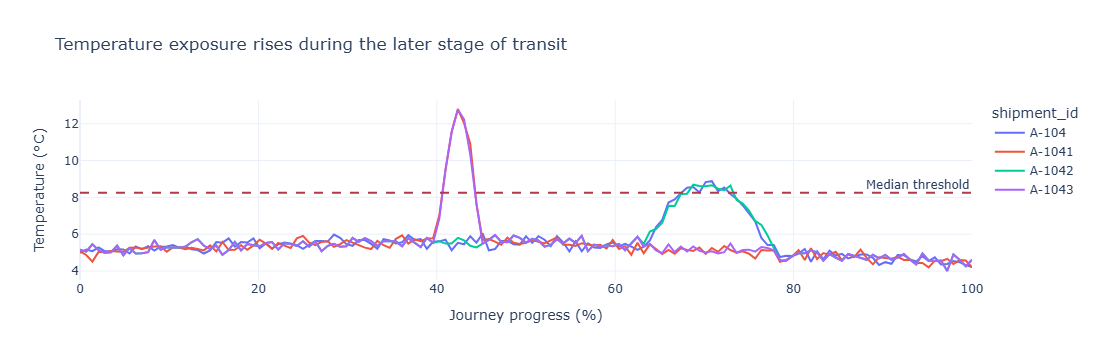

In [5]:
fig = px.line(shipments, x="journey_progress_pct", y="temperature_c", color="shipment_id",
              labels={"journey_progress_pct":"Journey progress (%)", "temperature_c":"Temperature (°C)"},
              title="Temperature exposure rises during the later stage of transit")
fig.add_hline(y=shipments["temp_threshold_c"].median(), line_dash="dash", line_color="#B23A48",
              annotation_text="Median threshold")
fig.update_layout(template="plotly_white")
fig.show()

## Q2. Alert readings concentrate in specific journey stages

**Interpretation objective:** This compares alert counts across both journey stage and shipment, linking temporal/spatial progress with risk.

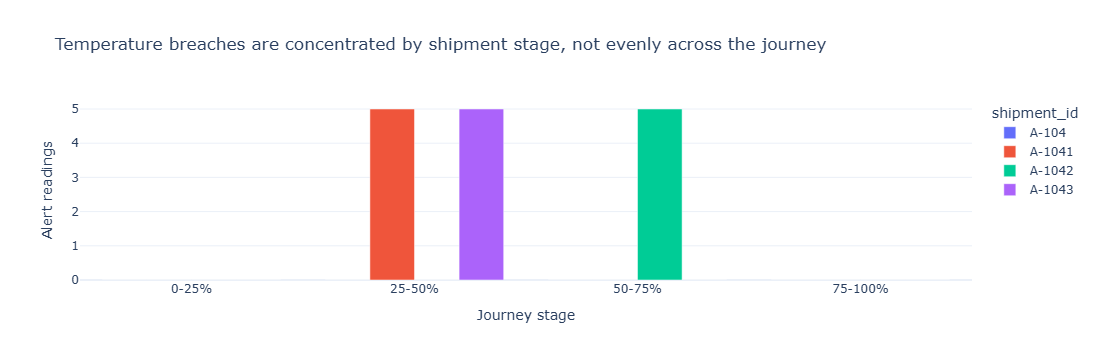

In [6]:
stage_alerts = shipments.groupby(["shipment_id","journey_stage"], observed=False)["alert"].sum().reset_index()
fig = px.bar(stage_alerts, x="journey_stage", y="alert", color="shipment_id", barmode="group",
             labels={"journey_stage":"Journey stage", "alert":"Alert readings"},
             title="Temperature breaches are concentrated by shipment stage, not evenly across the journey")
fig.update_layout(template="plotly_white")
fig.show()

## Q3. Unsafe exposure duration differs across shipments

**Interpretation objective:** This converts raw readings into exposure duration, a more decision-relevant risk measure.

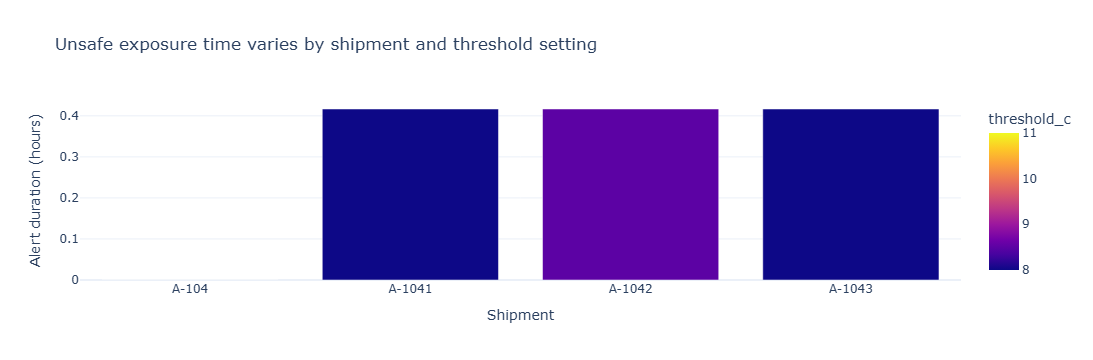

In [7]:
fig = px.bar(summary.sort_values("alert_duration_hours"), x="shipment_id", y="alert_duration_hours",
             color="threshold_c", labels={"alert_duration_hours":"Alert duration (hours)", "shipment_id":"Shipment"},
             title="Unsafe exposure time varies by shipment and threshold setting")
fig.update_layout(template="plotly_white")
fig.show()

## Q4. Temperature severity combines peak temperature and volatility

**Interpretation objective:** This relates variability, peak temperature, and alert frequency instead of using a single summary value.

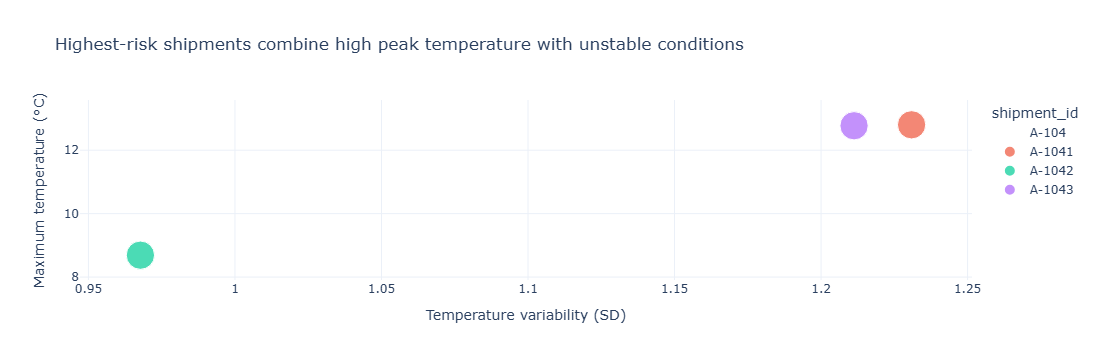

In [8]:
fig = px.scatter(summary, x="temperature_variability_sd", y="max_temperature_c", size="alert_readings", color="shipment_id",
                 labels={"temperature_variability_sd":"Temperature variability (SD)", "max_temperature_c":"Maximum temperature (°C)"},
                 title="Highest-risk shipments combine high peak temperature with unstable conditions")
fig.update_layout(template="plotly_white")
fig.show()

## Q5. Temperature variability by transit phase

**Interpretation objective:** This examines whether environmental stability shifts as the journey progresses.

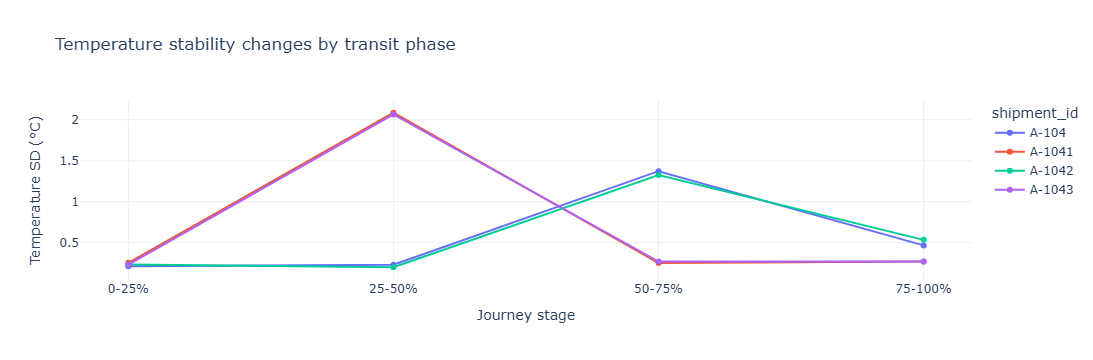

In [9]:
stage_var = shipments.groupby(["shipment_id","journey_stage"], observed=False)["temperature_c"].std().reset_index(name="temperature_sd")
fig = px.line(stage_var, x="journey_stage", y="temperature_sd", color="shipment_id", markers=True,
              labels={"journey_stage":"Journey stage", "temperature_sd":"Temperature SD (°C)"},
              title="Temperature stability changes by transit phase")
fig.update_layout(template="plotly_white")
fig.show()

## Q6. Emissions accumulate with distance, but totals differ by shipment

**Interpretation objective:** This links environmental footprint to shipment progress and shipment identity.

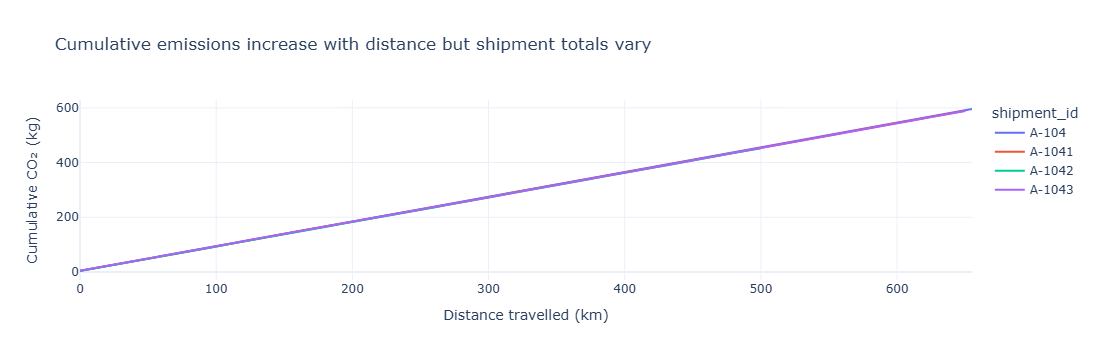

In [10]:
fig = px.line(shipments, x="distance_km", y="cumulative_co2_kg", color="shipment_id",
              labels={"distance_km":"Distance travelled (km)", "cumulative_co2_kg":"Cumulative CO₂ (kg)"},
              title="Cumulative emissions increase with distance but shipment totals vary")
fig.update_layout(template="plotly_white")
fig.show()

## Q7. High-emission intervals can be identified as operational outliers

**Interpretation objective:** This isolates high-emission readings and conditions them by shipment and time.

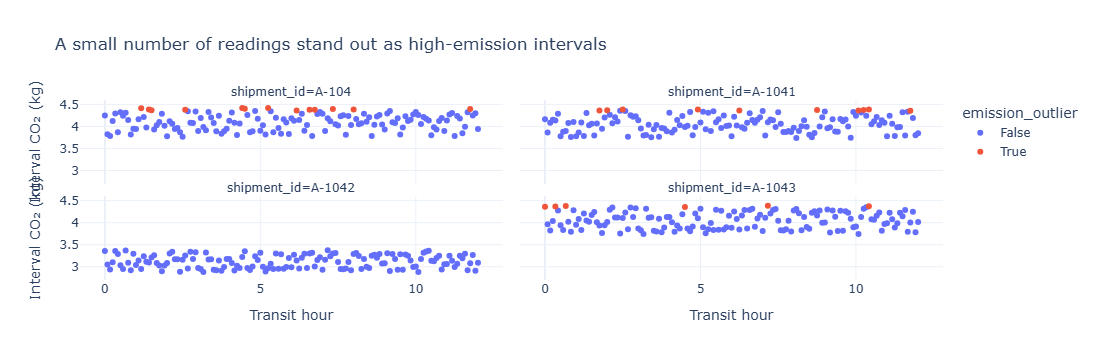

In [11]:
threshold = shipments["interval_co2_kg"].quantile(0.95)
shipments["emission_outlier"] = shipments["interval_co2_kg"] >= threshold
fig = px.scatter(shipments, x="hour", y="interval_co2_kg", color="emission_outlier", facet_col="shipment_id", facet_col_wrap=2,
                 labels={"hour":"Transit hour", "interval_co2_kg":"Interval CO₂ (kg)"},
                 title="A small number of readings stand out as high-emission intervals")
fig.update_layout(template="plotly_white")
fig.show()

## Q8. Real-time monitoring detects risk earlier than checkpoints

**Interpretation objective:** This directly answers the transparency question by comparing detection mechanisms.

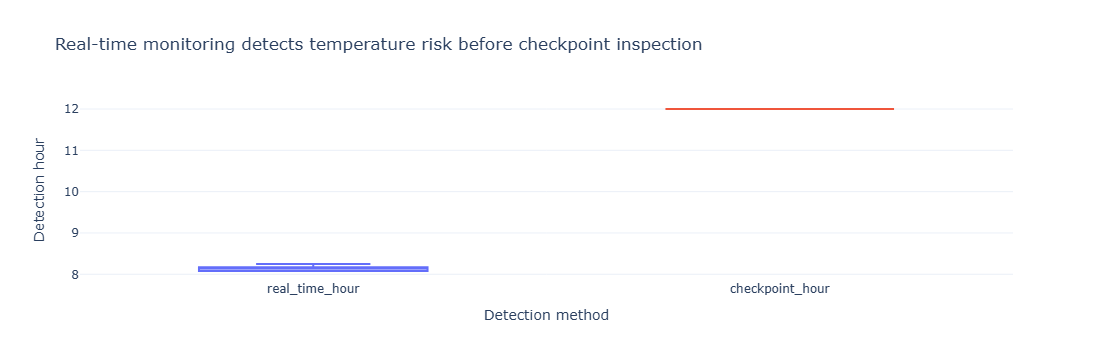

In [12]:
detect = batch[["real_time_hour","checkpoint_hour"]].melt(var_name="Detection method", value_name="Detection hour")
fig = px.box(detect, x="Detection method", y="Detection hour", color="Detection method",
             title="Real-time monitoring detects temperature risk before checkpoint inspection")
fig.update_layout(template="plotly_white", showlegend=False)
fig.show()

## Q9. The detection-time advantage is consistent across runs

**Interpretation objective:** This examines not just the average advantage but its consistency across repeated runs.

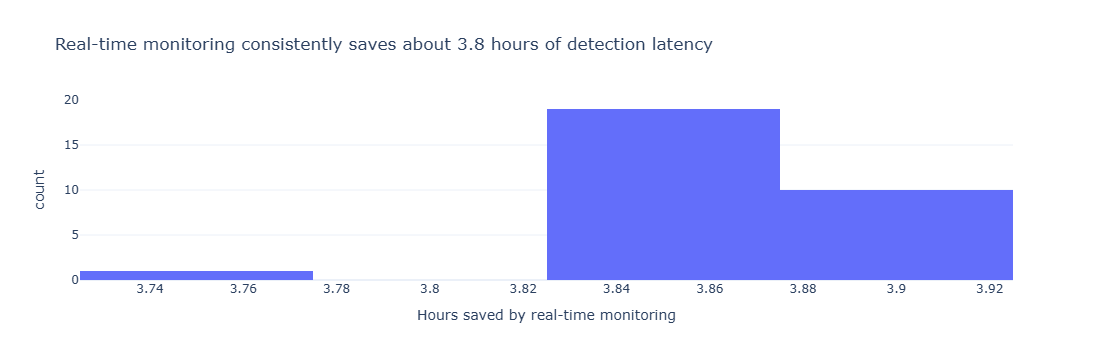

In [13]:
fig = px.histogram(batch, x="latency_hours", nbins=8,
                   labels={"latency_hours":"Hours saved by real-time monitoring"},
                   title="Real-time monitoring consistently saves about 3.8 hours of detection latency")
fig.update_layout(template="plotly_white")
fig.show()

## Q10. Combined operational risk score ranks shipments

**Interpretation objective:** This combines temperature severity, unsafe exposure time, and emissions into an action-oriented shipment ranking.

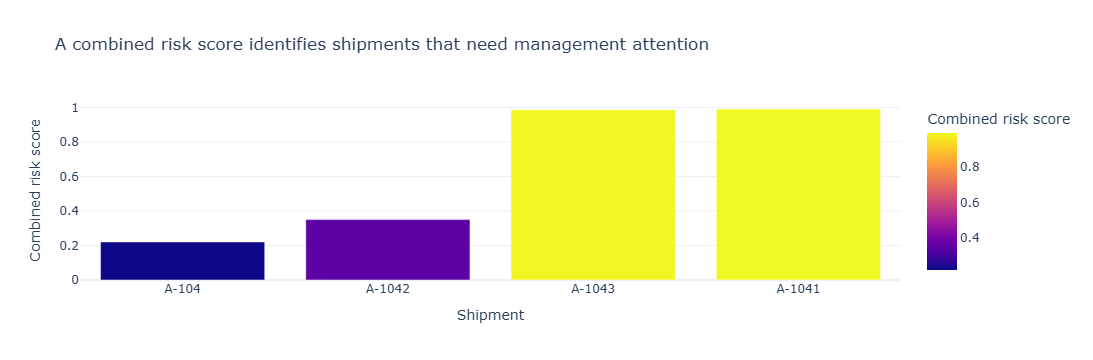

,shipment_id,max_temperature_c,alert_duration_hours,total_co2_kg,combined_risk_score
1,A-1041,12.80,0.416667,589.552,0.991188
3,A-1043,12.77,0.416667,588.416,0.986318
2,A-1042,8.69,0.416667,452.621,0.350000
0,A-104,8.88,0.000000,595.863,0.220803


In [14]:
risk = summary.copy()
risk["temp_score"] = (risk["max_temperature_c"] - risk["max_temperature_c"].min()) / (risk["max_temperature_c"].max() - risk["max_temperature_c"].min())
risk["alert_score"] = (risk["alert_duration_hours"] - risk["alert_duration_hours"].min()) / (risk["alert_duration_hours"].max() - risk["alert_duration_hours"].min())
risk["co2_score"] = (risk["total_co2_kg"] - risk["total_co2_kg"].min()) / (risk["total_co2_kg"].max() - risk["total_co2_kg"].min())
risk = risk.fillna(0)
risk["combined_risk_score"] = 0.45*risk["temp_score"] + 0.35*risk["alert_score"] + 0.20*risk["co2_score"]
fig = px.bar(risk.sort_values("combined_risk_score"), x="shipment_id", y="combined_risk_score",
             color="combined_risk_score", labels={"combined_risk_score":"Combined risk score", "shipment_id":"Shipment"},
             title="A combined risk score identifies shipments that need management attention")
fig.update_layout(template="plotly_white")
fig.show()
risk[["shipment_id","max_temperature_c","alert_duration_hours","total_co2_kg","combined_risk_score"]].sort_values("combined_risk_score", ascending=False)

## Dashboard and presentation connection

The Streamlit dashboard uses a curated subset of the notebook visuals: KPI overview, route monitoring, sensor trends, alert log, and detection-speed comparison. The presentation deck summarizes the project story and should include dashboard screenshots after deployment.

 Analytical Questions and Visualisations

## Question 1: How does temperature vary across the shipments?

**Objective**

This analysis investigates the temperature patterns recorded during each shipment. Maintaining the correct temperature is essential for preserving product quality and preventing spoilage. By comparing temperatures across shipments, we can identify shipments with greater temperature fluctuations or potential cold-chain failures.

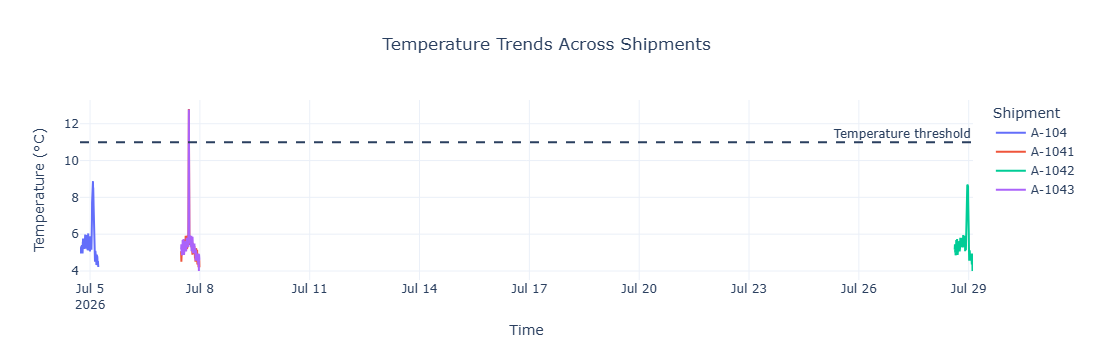

In [15]:

import plotly.express as px

fig = px.line(
    shipments,
    x="timestamp",
    y="temperature_c",
    color="shipment_id",
    title="Temperature Trends Across Shipments",
    labels={
        "timestamp": "Time",
        "temperature_c": "Temperature (°C)",
        "shipment_id": "Shipment"
    }
)

fig.add_hline(
    y=shipments["temp_threshold_c"].iloc[0],
    line_dash="dash",
    annotation_text="Temperature threshold"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    hovermode="x unified"
)

fig.show()

### Interpretation

The line chart illustrates how temperature changes throughout each shipment. Comparing the temperature profiles allows us to identify periods of stability and periods where temperatures deviate from the expected operating range.

Large fluctuations may indicate environmental exposure, equipment malfunction, or delays during transportation. Stable temperature profiles demonstrate effective cold-chain management and reduce the risk of product deterioration.

These findings help logistics managers identify shipments requiring additional monitoring and improve future transportation planning.

## Question 2: Which shipment generated the highest number of alerts?

**Objective**

This analysis identifies the shipments that triggered the highest number of alerts. Frequent alerts may indicate recurring operational issues, equipment failures, or environmental conditions that require attention.

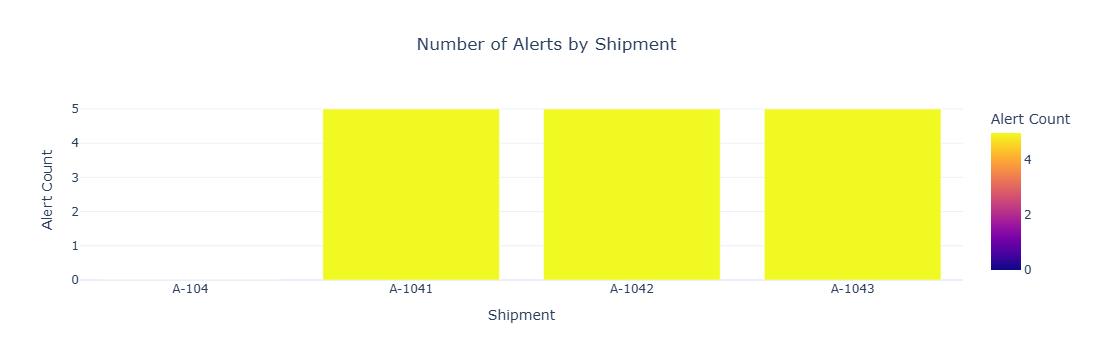

In [16]:
import plotly.express as px

alert_counts = (
    shipments.groupby("shipment_id")["alert"]
    .sum()
    .reset_index(name="Number of Alerts")
)

fig = px.bar(
    alert_counts,
    x="shipment_id",
    y="Number of Alerts",
    color="Number of Alerts",
    title="Number of Alerts by Shipment",
    labels={
        "shipment_id": "Shipment",
        "Number of Alerts": "Alert Count"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

### Interpretation

The bar chart compares the number of alerts generated by each shipment. A higher number of alerts suggests that a shipment experienced more operational anomalies, such as temperature threshold breaches or other monitored risks.

Shipments with consistently high alert counts should be prioritised for further investigation to determine whether the issues stem from equipment performance, transport delays, or external environmental conditions.

Monitoring alert frequency enables logistics managers to improve preventive maintenance strategies and enhance the reliability of future shipments.

## Question 3: What is the relationship between temperature and carbon emissions?

### Objective

This analysis investigates whether there is a relationship between shipment temperature and the amount of carbon dioxide (CO₂) emitted during transportation. Understanding this relationship helps determine whether environmental conditions are associated with increased transport emissions.

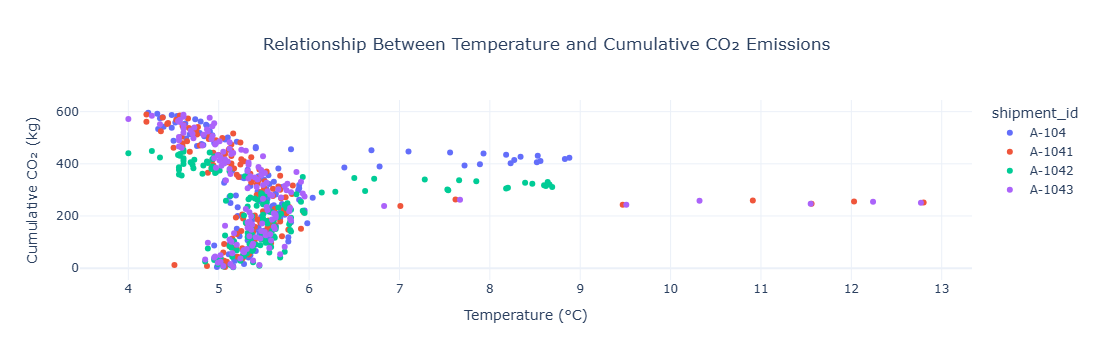

In [17]:
import plotly.express as px

fig = px.scatter(
    shipments,
    x="temperature_c",
    y="cumulative_co2_kg",
    color="shipment_id",
    hover_data=["journey_stage"],
    title="Relationship Between Temperature and Cumulative CO₂ Emissions"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Temperature (°C)",
    yaxis_title="Cumulative CO₂ (kg)"
)

fig.show()

### Interpretation

The scatter plot illustrates the relationship between shipment temperature and cumulative CO₂ emissions. Each point represents a recorded sensor observation during transportation.

If the points display an upward trend, higher temperatures may coincide with increased emissions, potentially reflecting longer transport durations, increased refrigeration effort, or operational inefficiencies. Conversely, a weak or random pattern suggests that temperature and emissions are largely independent.

Understanding this relationship enables logistics managers to optimise transport operations while balancing product quality with environmental sustainability.

## Question 4: Which journey stage experiences the highest temperatures?

### Objective

This analysis examines how temperatures vary across different stages of the shipment journey. Identifying stages with higher temperatures helps logistics managers understand where cold-chain risks are most likely to occur.

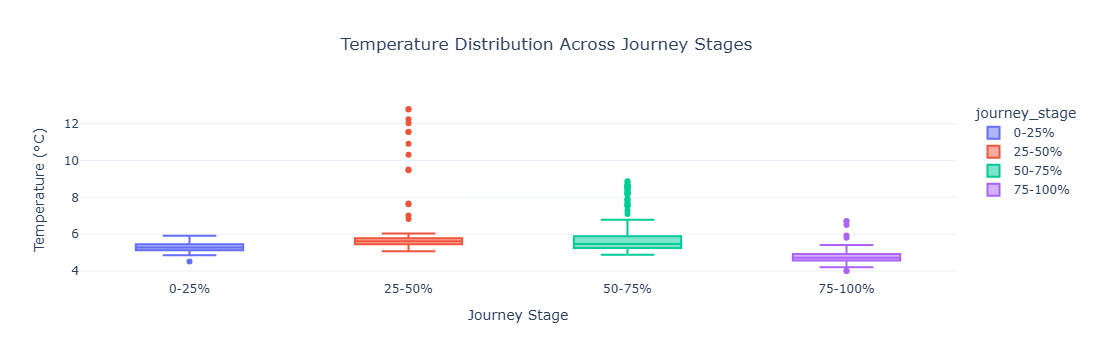

In [18]:
import plotly.express as px

fig = px.box(
    shipments,
    x="journey_stage",
    y="temperature_c",
    color="journey_stage",
    title="Temperature Distribution Across Journey Stages"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Journey Stage",
    yaxis_title="Temperature (°C)"
)

fig.show()

### Interpretation

The box plot compares temperature distributions across the different journey stages. It highlights both the average operating temperature and the variability observed at each stage.

Journey stages with larger spreads or higher median temperatures may indicate increased exposure to environmental conditions or operational delays. These stages should be prioritised for additional monitoring and preventive action.

The findings support logistics managers in identifying vulnerable segments of the transport process and improving temperature control strategies throughout the supply chain.

## Question 5: Which shipments have the highest operational risk?

### Objective

This analysis evaluates the distribution of operational risk levels across all shipments. Understanding the frequency of low, medium, and high-risk events enables logistics managers to prioritise interventions and improve supply chain resilience.

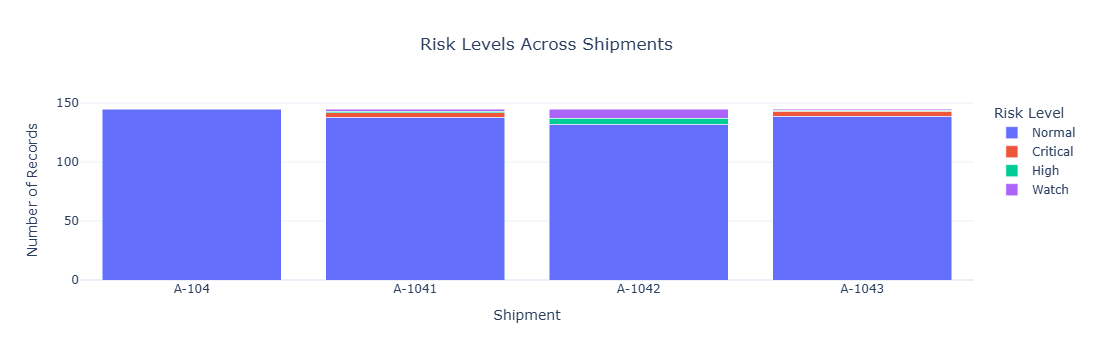

In [19]:
import plotly.express as px

risk_counts = (
    shipments.groupby(["shipment_id", "risk_level"])
    .size()
    .reset_index(name="Count")
)

fig = px.bar(
    risk_counts,
    x="shipment_id",
    y="Count",
    color="risk_level",
    barmode="stack",
    title="Risk Levels Across Shipments",
    labels={
        "shipment_id": "Shipment",
        "Count": "Number of Records",
        "risk_level": "Risk Level"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

### Interpretation

The stacked bar chart illustrates the distribution of operational risk levels for each shipment. The colours distinguish between low, medium, and high-risk observations, making it easy to identify shipments that require closer attention.

Shipments with a higher proportion of high-risk records may have experienced repeated environmental issues, delays, or temperature threshold breaches. Conversely, shipments dominated by low-risk observations demonstrate more stable operating conditions.

These findings support risk-based decision-making by helping logistics managers prioritise inspections, improve monitoring strategies, and allocate resources to the most vulnerable shipments.

## Question 6: At what time of day do temperature alerts occur most frequently?

### Objective

This analysis investigates whether temperature alerts are concentrated during particular periods of the day. Identifying these periods helps logistics managers optimise monitoring schedules and implement preventive measures when the likelihood of temperature breaches is highest.

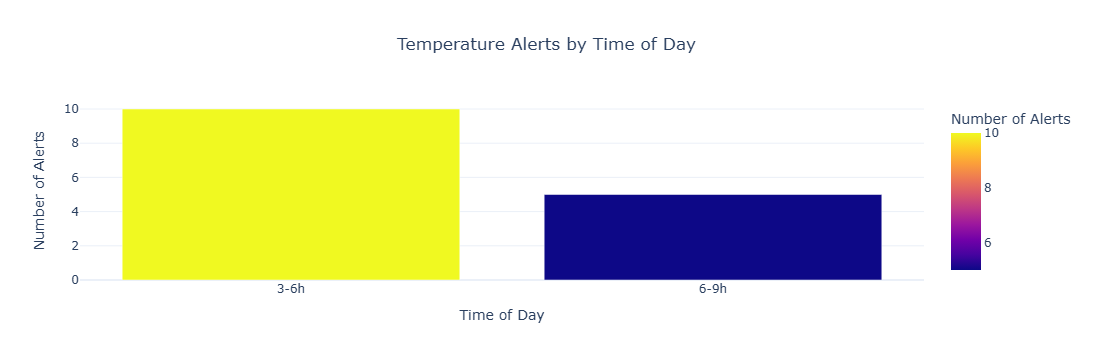

In [20]:
import plotly.express as px

alert_hours = (
    shipments[shipments["temp_alert"] == True]
    .groupby("hour_bucket")
    .size()
    .reset_index(name="Temperature Alerts")
)

fig = px.bar(
    alert_hours,
    x="hour_bucket",
    y="Temperature Alerts",
    color="Temperature Alerts",
    title="Temperature Alerts by Time of Day",
    labels={
        "hour_bucket": "Time of Day",
        "Temperature Alerts": "Number of Alerts"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

### Interpretation

The chart shows how temperature alerts are distributed throughout different periods of the day. Peaks in alert frequency indicate time windows during which shipments are more likely to experience temperature threshold breaches.

These patterns may be influenced by environmental conditions, traffic delays, loading and unloading activities, or prolonged vehicle stops. Understanding when alerts occur most frequently enables logistics managers to schedule additional monitoring and improve operational planning.

By focusing resources on high-risk periods, organisations can strengthen cold-chain reliability and reduce the likelihood of product spoilage.

## Question 7: How does journey progress influence cumulative CO₂ emissions?

### Objective

This analysis examines how cumulative carbon dioxide emissions increase as shipments progress through their journeys. Understanding this relationship provides insight into the environmental impact of transportation over distance and time.

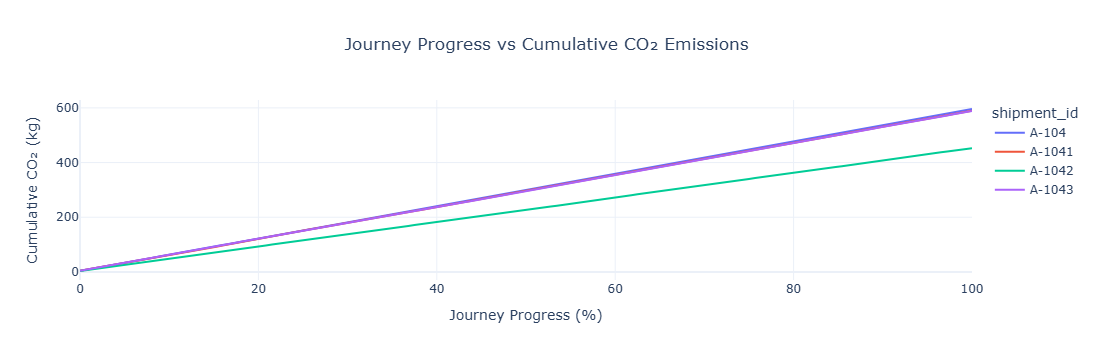

In [21]:
import plotly.express as px

fig = px.line(
    shipments,
    x="journey_progress_pct",
    y="cumulative_co2_kg",
    color="shipment_id",
    title="Journey Progress vs Cumulative CO₂ Emissions",
    labels={
        "journey_progress_pct": "Journey Progress (%)",
        "cumulative_co2_kg": "Cumulative CO₂ (kg)"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

### Interpretation

The line chart illustrates how cumulative CO₂ emissions increase as shipments progress from origin to destination. Since emissions accumulate throughout transportation, an upward trend is expected.

Differences between shipments may reflect variations in operational efficiency, route conditions, or transport duration. Shipments with steeper increases in emissions may indicate opportunities for optimisation, such as route improvements or more efficient vehicle utilisation.

This analysis supports sustainability initiatives by helping organisations identify where environmental performance can be improved while maintaining operational effectiveness.

## Question 8: Which journey stages contribute the most to cumulative CO₂ emissions?

### Objective

This analysis examines cumulative carbon dioxide (CO₂) emissions across the different stages of the shipment journey. Understanding where emissions accumulate most helps organisations identify opportunities to improve environmental sustainability and transportation efficiency.

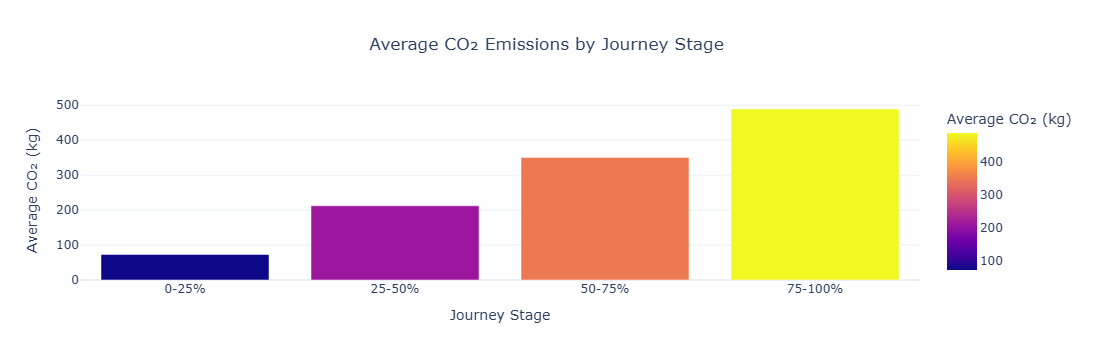

In [22]:
import plotly.express as px

stage_emissions = (
    shipments.groupby("journey_stage")["cumulative_co2_kg"]
    .mean()
    .reset_index()
)

fig = px.bar(
    stage_emissions,
    x="journey_stage",
    y="cumulative_co2_kg",
    color="cumulative_co2_kg",
    title="Average CO₂ Emissions by Journey Stage",
    labels={
        "journey_stage": "Journey Stage",
        "cumulative_co2_kg": "Average CO₂ (kg)"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

### Interpretation

The chart compares the average cumulative CO₂ emissions across the different journey stages. Higher emission values indicate stages where transportation activities contribute more significantly to environmental impact.

These findings help logistics managers identify stages that may benefit from route optimisation, improved vehicle efficiency, or alternative transportation methods to reduce emissions.

## Question 9: Which shipments contain carbon emission outliers?

### Objective

This analysis identifies shipments containing unusually high carbon emissions. Outliers may indicate operational inefficiencies, unexpected delays, or environmental conditions that require further investigation.

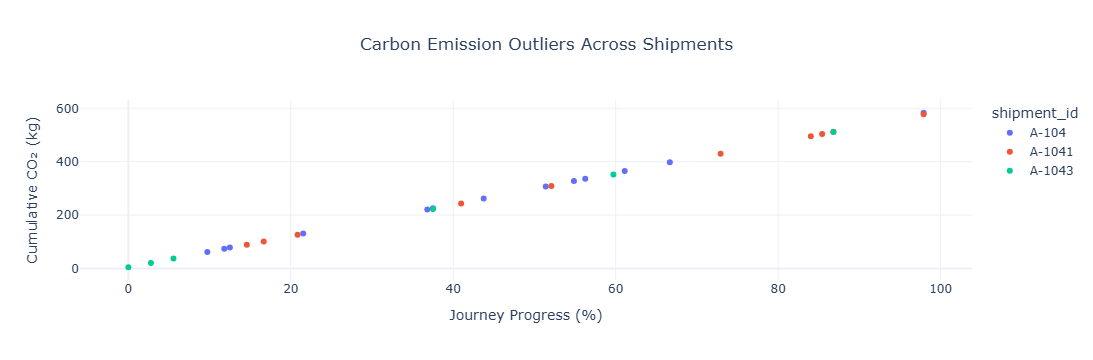

In [23]:
import plotly.express as px

outliers = shipments[shipments["emission_outlier"] == True]

fig = px.scatter(
    outliers,
    x="journey_progress_pct",
    y="cumulative_co2_kg",
    color="shipment_id",
    title="Carbon Emission Outliers Across Shipments",
    labels={
        "journey_progress_pct": "Journey Progress (%)",
        "cumulative_co2_kg": "Cumulative CO₂ (kg)"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

### Interpretation

The scatter plot highlights observations classified as carbon emission outliers. These points represent unusually high emissions compared with the remainder of the shipment data.

Investigating these observations can help organisations understand whether they result from longer transport durations, traffic congestion, equipment performance, or inefficient routing. Addressing these factors supports both operational efficiency and sustainability objectives.

## Question 10: Which shipments experienced the greatest temperature deviation from the threshold?

### Objective

This analysis examines the magnitude of temperature deviations from the acceptable threshold for each shipment. Large deviations may indicate cold-chain failures or operational issues requiring immediate attention.

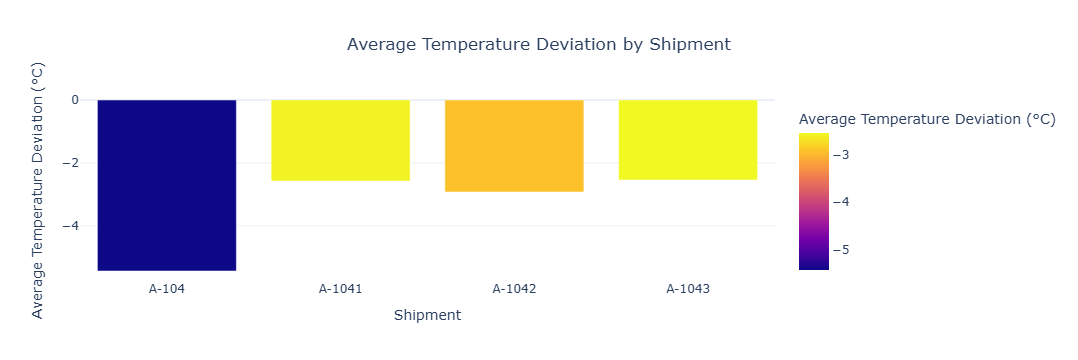

In [24]:
import plotly.express as px

deviation = (
    shipments.groupby("shipment_id")["temperature_difference_c"]
    .mean()
    .reset_index()
)

fig = px.bar(
    deviation,
    x="shipment_id",
    y="temperature_difference_c",
    color="temperature_difference_c",
    title="Average Temperature Deviation by Shipment",
    labels={
        "shipment_id": "Shipment",
        "temperature_difference_c": "Average Temperature Deviation (°C)"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

### Interpretation

The chart compares the average temperature deviation recorded for each shipment. Larger deviations indicate that a shipment spent more time operating outside the desired temperature range, increasing the likelihood of product spoilage and reduced product quality.

This analysis enables logistics managers to identify shipments requiring further investigation and supports improvements to refrigeration systems, route planning, and operational monitoring.

# Overall Findings and Recommendations

## Key Findings

The analysis demonstrates that IoT sensor data provides valuable insights into shipment performance, environmental conditions, operational risk, and sustainability.

Temperature monitoring successfully identified threshold breaches, while risk analysis highlighted shipments requiring additional operational attention. Carbon emission analysis illustrated how environmental impact accumulates throughout the transport journey, providing opportunities for optimisation.

## Recommendations

1. Increase monitoring during journey stages associated with elevated operational risk.
2. Investigate shipments with frequent temperature alerts to minimise product spoilage.
3. Optimise transportation routes to reduce cumulative carbon emissions.
4. Implement predictive analytics to identify high-risk shipments before threshold breaches occur.
5. Continue integrating IoT sensors into logistics operations to improve visibility, sustainability, and decision-making.

## Conclusion

This project demonstrates how interactive data visualisation and IoT sensor analytics can support evidence-based decision-making within modern supply chains. The Streamlit dashboard complements the notebook by providing an interactive environment for monitoring shipment performance and operational risk in real time.